# Image Processing for Input Data

In [1]:
#pip install --upgrade pyvista nibabel

In [7]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
import os
import math

# ==============================================================================
# HELPER FUNCTION 1: 50x50x50 Cropping Logic (As Provided)
# ==============================================================================

def _find_top_indices_and_crop(mri_vol, us_vol, axis, num_slices):
    """Internal helper function to find the most active slices along an axis and crop."""
    if num_slices > us_vol.shape[axis]:
        num_slices = us_vol.shape[axis]
    other_axes = tuple(ax for ax in [0, 1, 2] if ax != axis)
    active_pixel_counts = np.count_nonzero(us_vol, axis=other_axes)
    top_indices = np.argsort(active_pixel_counts)[-num_slices:]
    top_indices_sorted = np.sort(top_indices)
    mri_cropped = np.take(mri_vol, top_indices_sorted, axis=axis)
    us_cropped = np.take(us_vol, top_indices_sorted, axis=axis)
    return mri_cropped, us_cropped

def crop_50x50x50_and_save(mri_path_in, us_path_in, mri_path_out, us_path_out, label=None):
    """
    Loads, aligns, iteratively crops to a 50x50x50 cube, saves the result,
    and returns the final volumes for plotting.
    """
    print(f"--- Processing {label or mri_path_in} ---")
    try:
        mri_img = nib.load(mri_path_in)
        us_img = nib.load(us_path_in)
        mri_data = mri_img.get_fdata()
        us_data = us_img.get_fdata()
        mri_affine = mri_img.affine
        us_affine = us_img.affine
        
        inv_us_affine = np.linalg.inv(us_affine)
        mri_to_us_transform = inv_us_affine @ mri_affine
        us_resampled = affine_transform(
            us_data, mri_to_us_transform, output_shape=mri_data.shape, order=1, cval=0.0
        )
    except FileNotFoundError as e:
        print(f"Error: {e}. Skipping this file pair.")
        return None, None

    # Iteratively crop to 50x50x50
    CROP_SIZE = 50
    mri_c1, us_c1 = _find_top_indices_and_crop(mri_data, us_resampled, axis=0, num_slices=CROP_SIZE)
    mri_c2, us_c2 = _find_top_indices_and_crop(mri_c1, us_c1, axis=1, num_slices=CROP_SIZE)
    mri_final, us_final = _find_top_indices_and_crop(mri_c2, us_c2, axis=2, num_slices=CROP_SIZE)
    
    print(f"Final cropped shape for {label}: {mri_final.shape}")
    
    # Save the final cropped volumes
    try:
        output_dir = os.path.dirname(mri_path_out)
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        
        nib.save(nib.Nifti1Image(mri_final, mri_affine), mri_path_out)
        nib.save(nib.Nifti1Image(us_final, mri_affine), us_path_out)
        print(f"Successfully saved files for {label}\n")
    except Exception as e:
        print(f"Error saving files for {label}: {e}\n")

    return mri_final, us_final

# ==============================================================================
# HELPER FUNCTION 2: Individual Histogram Plotting
# ==============================================================================

def plot_individual_histogram(ax, us_vol, label, color):
    """Plots a single histogram onto a specific subplot axis."""
    if us_vol is None or us_vol.shape != (50, 50, 50):
        ax.text(0.5, 0.5, f'Invalid Shape:\n{us_vol.shape if us_vol is not None else "None"}', 
                ha='center', va='center', color='red')
        ax.set_title(label, fontsize=10)
        return

    active_pixel_counts = [np.count_nonzero(us_vol[i, :, :]) for i in range(us_vol.shape[0])]
    slice_indices = np.arange(len(active_pixel_counts))
    
    ax.bar(slice_indices, active_pixel_counts, color=color)
    ax.set_title(label, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim(0, 2500) # Set a uniform Y-axis for better comparison

==================== STARTING 50x50x50 CROPPING PIPELINE ====================
--- Processing Patient 1 ---
Final cropped shape for Patient 1: (50, 50, 50)
Successfully saved files for Patient 1

--- Processing Patient 2 ---
Final cropped shape for Patient 2: (50, 50, 50)
Successfully saved files for Patient 2

--- Processing Patient 3 ---
Final cropped shape for Patient 3: (50, 50, 50)
Successfully saved files for Patient 3

--- Processing Patient 4 ---
Final cropped shape for Patient 4: (50, 50, 50)
Successfully saved files for Patient 4

--- Processing Patient 5 ---
Final cropped shape for Patient 5: (50, 50, 50)
Successfully saved files for Patient 5

--- Processing Patient 6 ---
Final cropped shape for Patient 6: (50, 50, 50)
Successfully saved files for Patient 6

--- Processing Patient 7 ---
Final cropped shape for Patient 7: (50, 50, 50)
Successfully saved files for Patient 7

--- Processing Patient 8 ---
Final cropped shape for Patient 8: (50, 50, 50)
Successfully saved files f

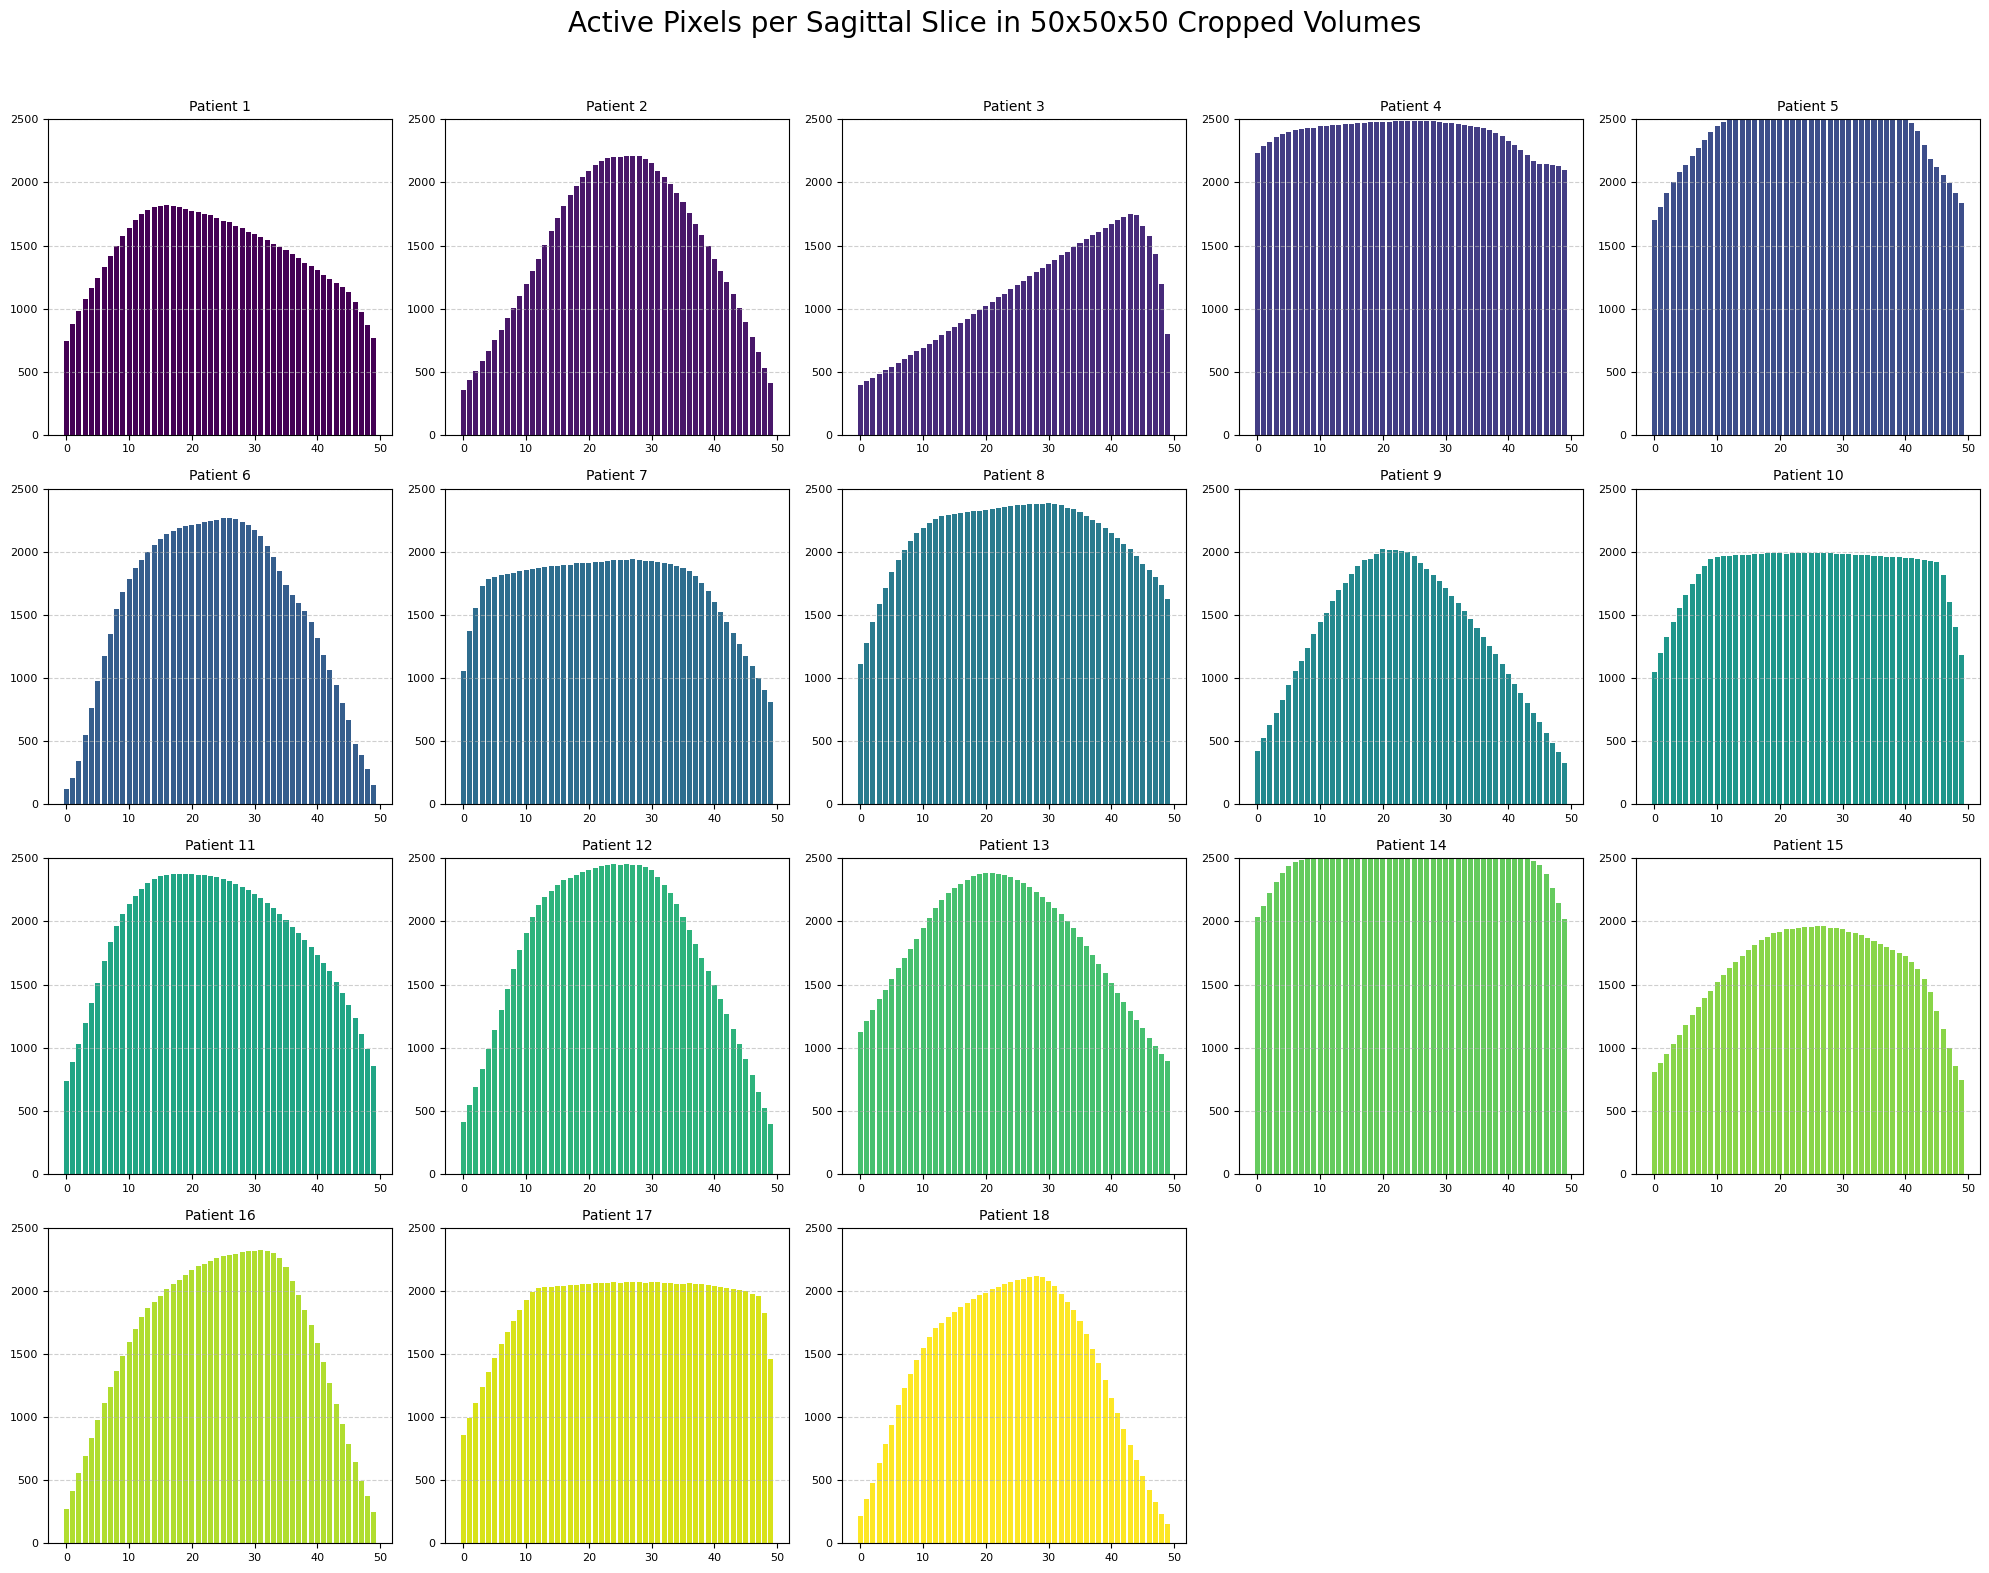

In [11]:
# ==============================================================================
# Main Execution Block
# ==============================================================================

# --- 1. Define Input Data and Generate Output Paths ---
file_pairs_in = [
    ("RawData/Case1-FLAIR.nii.gz", "RawData/Case1-US-during.nii.gz"),
    ("RawData/Case2-FLAIR.nii.gz", "RawData/Case2-US-during.nii.gz"),
    ("RawData/Case3-FLAIR.nii.gz", "RawData/Case3-US-during.nii.gz"),
    ("RawData/Case5-FLAIR.nii.gz", "RawData/Case5-US-during.nii.gz"),
    ("RawData/Case7-FLAIR.nii.gz", "RawData/Case7-US-during.nii.gz"),
    ("RawData/Case8-FLAIR.nii.gz", "RawData/Case8-US-during.nii.gz"),
    ("RawData/Case12-FLAIR.nii.gz", "RawData/Case12-US-during.nii.gz"),
    ("RawData/Case13-FLAIR.nii.gz", "RawData/Case13-US-during.nii.gz"),
    ("RawData/Case14-FLAIR.nii.gz", "RawData/Case14-US-during.nii.gz"),
    ("RawData/Case15-FLAIR.nii.gz", "RawData/Case15-US-during.nii.gz"),
    ("RawData/Case17-FLAIR.nii.gz", "RawData/Case17-US-during.nii.gz"),
    ("RawData/Case18-FLAIR.nii.gz", "RawData/Case18-US-during.nii.gz"),
    ("RawData/Case19-FLAIR.nii.gz", "RawData/Case19-US-during.nii.gz"),
    ("RawData/Case21-FLAIR.nii.gz", "RawData/Case21-US-during.nii.gz"),
    ("RawData/Case23-FLAIR.nii.gz", "RawData/Case23-US-during.nii.gz"),
    ("RawData/Case25-FLAIR.nii.gz", "RawData/Case25-US-during.nii.gz"),
    ("RawData/Case26-FLAIR.nii.gz", "RawData/Case26-US-during.nii.gz"),
    ("RawData/Case27-FLAIR.nii.gz", "RawData/Case27-US-during.nii.gz"),
]

# Automatically generate sequential output paths and labels from 1 to N
file_pairs_out, plot_labels = [], []

# Use enumerate(..., start=1) to get a simple counter 'i' (1, 2, 3, ...)
for i, (mri_in_path, _) in enumerate(file_pairs_in, start=1):
    
    # Create the new sequential case ID string, e.g., "Case1", "Case2"
    case_id_str = f"Case{i}"
    
    # Create the new sequential plot label, e.g., "Patient 1", "Patient 2"
    plot_labels.append(f"Patient {i}")
    
    # Create the new output file paths using the sequential ID
    file_pairs_out.append((
        f"INPUT/{case_id_str}-FLAIR.nii.gz",
        f"INPUT/{case_id_str}-US-during.nii.gz"
    ))
    
plot_colors = plt.cm.viridis(np.linspace(0, 1, len(file_pairs_in)))

# --- 2. Process, Save, and Collect Data ---
print("="*20, "STARTING 50x50x50 CROPPING PIPELINE", "="*20)
all_cropped_data = {} # Initialize dictionary to store data for plotting

for i, ((mri_in, us_in), (mri_out, us_out)) in enumerate(zip(file_pairs_in, file_pairs_out)):
    label = plot_labels[i]
    _, us_processed = crop_50x50x50_and_save(
        mri_path_in=mri_in, us_path_in=us_in,
        mri_path_out=mri_out, us_path_out=us_out,
        label=label
    )
    if us_processed is not None:
        all_cropped_data[label] = us_processed

print("="*20, "PROCESSING COMPLETE", "="*20)

# --- 3. PLOT ALL HISTOGRAMS ON A GRID ---
print("\n" + "="*20, "STARTING HISTOGRAM PLOTTING", "="*20)

if all_cropped_data:
    num_patients = len(all_cropped_data)
    ncols = 5
    nrows = math.ceil(num_patients / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
    fig.suptitle('Active Pixels per Sagittal Slice in 50x50x50 Cropped Volumes', fontsize=20)
    
    axes_flat = axes.flatten()
    
    for i, label in enumerate(all_cropped_data.keys()):
        us_volume = all_cropped_data[label]
        ax = axes_flat[i]
        color_index = plot_labels.index(label)
        
        plot_individual_histogram(
            ax=ax,
            us_vol=us_volume,
            label=label,
            color=plot_colors[color_index]
        )
    
    # Hide any unused subplots
    for j in range(num_patients, len(axes_flat)):
        axes_flat[j].set_visible(False)
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("No data was successfully processed to create a plot.")